<a href="https://colab.research.google.com/github/biglalo104/Projects/blob/main/Predict%20Fuel%20Efficiency%20Using%20Tensorflow%20in%20Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

import tensorflow as tf
from tensorflow import keras
from keras import layers

import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('auto-mpg.csv')
print(df.head())

    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


In [3]:
df.shape

(398, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [5]:
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [6]:
df['horsepower'].unique()

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '?', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

In [8]:
print(df.shape)
df = df[df['horsepower'] != '']
print(df.shape)

(398, 9)
(398, 9)


In [11]:
df['horsepower'] = df['horsepower'].replace('?', np.nan)
df['horsepower'] = pd.to_numeric(df['horsepower'])
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mean())
df['horsepower'] = df['horsepower'].astype(int)
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [12]:
df.nunique()

,0
mpg,129
cylinders,5
displacement,82
horsepower,94
weight,351
acceleration,95
model year,13
origin,3
car name,305


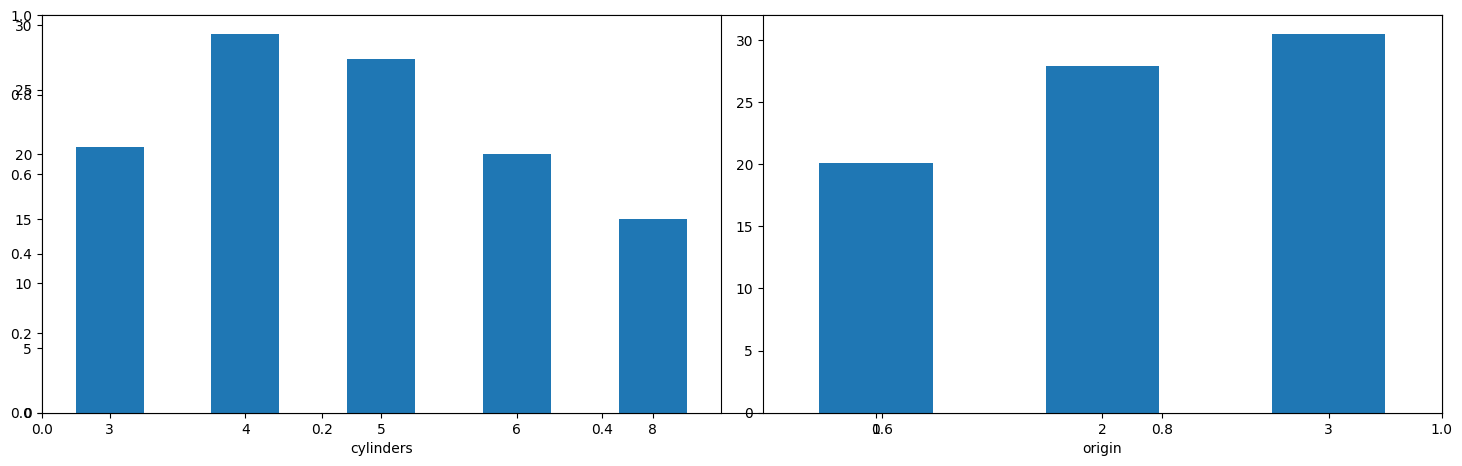

In [13]:
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=['number'])

plt.subplots(figsize=(15,5))
for i,col in enumerate(['cylinders','origin']):
  plt.subplot(1,2,i+1)
  x = numeric_df.groupby(col).mean()['mpg']
  x.plot.bar()
  plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

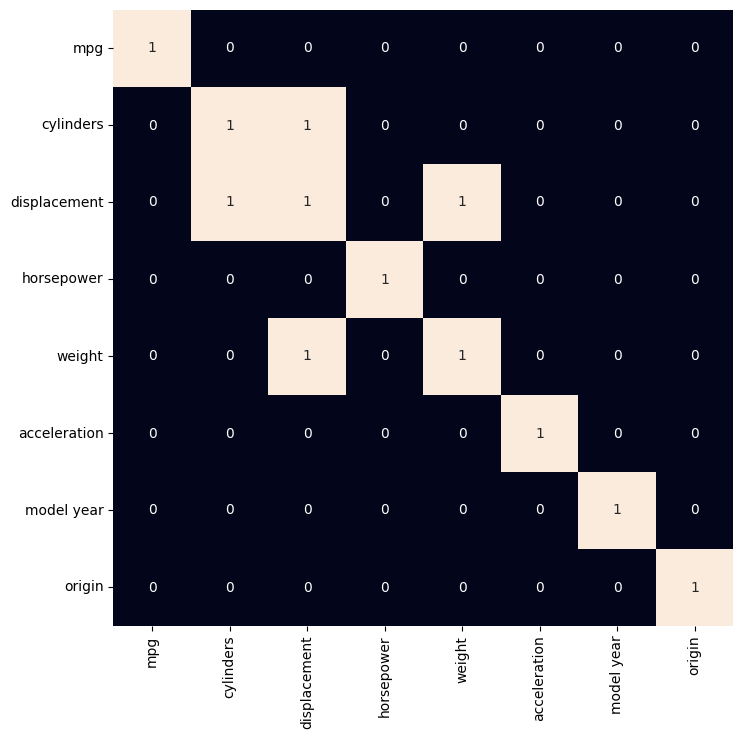

In [14]:
plt.figure(figsize=(8,8))
sb.heatmap(numeric_df.corr() >0.9,annot=True,cbar=False)
plt.show()

In [15]:
df.drop('displacement',axis=1,inplace=True)

In [16]:
from sklearn.model_selection import train_test_split
features = df.drop(['mpg','car name'],axis=1)
target = df['mpg'].values

X_train,X_val, \
    Y_train,Y_val = train_test_split(features,target,test_size=0.2,random_state=22)

X_train.shape,X_val.shape


((318, 6), (80, 6))

In [18]:
AUTO = tf.data.experimental.AUTOTUNE

trains_ds = tf.data.Dataset.from_tensor_slices((X_train,Y_train)).batch(32).prefetch(AUTO)
val_ds = tf.data.Dataset.from_tensor_slices((X_val,Y_val)).batch(32).prefetch(AUTO)

In [19]:
model = keras.Sequential([layers.Dense(256,activation = 'relu',input_shape=[6]),layers.BatchNormalization(),layers.Dense(256,activation='relu'),layers.Dropout(0.3),layers.BatchNormalization(),layers.Dense(1,activation='relu')])

In [20]:
model.compile(loss='mae',optimizer='adam',metrics=['mape'])

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,889 (273.00 KB)

 Trainable params: 68,865 (269.00 KB)

 Non-trainable params: 1,024 (4.00 KB)

In [24]:
history = model.fit(trains_ds,epochs=50,validation_data=val_ds)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 22.4022 - mape: 94.7931 - val_loss: 24.0625 - val_mape: 100.0000
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 20.3774 - mape: 81.1524 - val_loss: 12.0139 - val_mape: 51.6135
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 19.0080 - mape: 72.9114 - val_loss: 13.7330 - val_mape: 69.9482
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18.3909 - mape: 70.0353 - val_loss: 12.9838 - val_mape: 62.1013
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 17.6898 - mape: 66.3948 - val_loss: 11.9809 - val_mape: 52.5298
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 17.1584 - mape: 63.9202 - val_loss: 11.4434 - val_mape: 46.5066
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 16.5648 - mape: 61.1184 - val_loss: 10.8773 - val_mape: 41.3883
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 15.9983 - mape: 58.6985 - val_loss: 10.3833 - val_mape: 37.2139
Epoch 9/50
10/10 ━━━━━

In [25]:
history_df = pd.DataFrame(history.history)
history_df.head()

,loss,mape,val_loss,val_mape
0,22.402168,94.793076,24.062500,100.000000
1,20.377388,81.152405,12.013882,51.613483
2,19.007984,72.911430,13.732965,69.948189
3,18.390913,70.035316,12.983795,62.101307
4,17.689842,66.394768,11.980861,52.529793


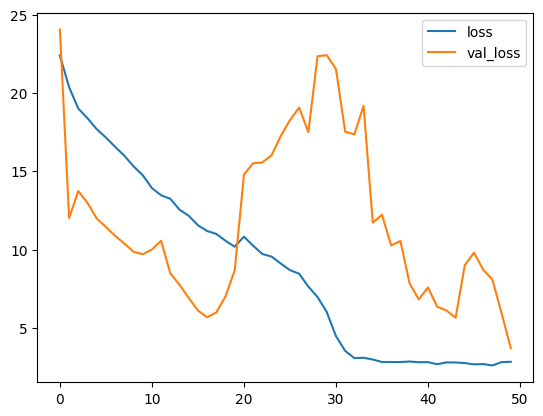

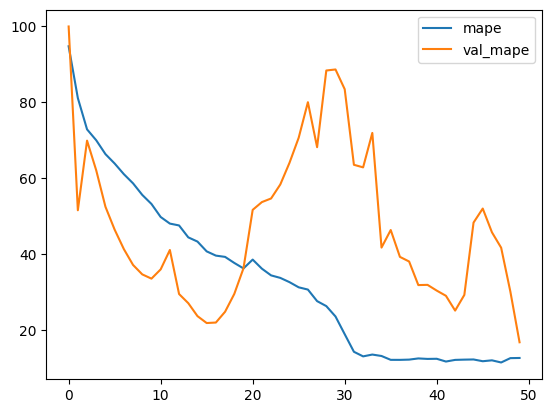

In [27]:
history_df.loc[:,['loss','val_loss']].plot()
history_df.loc[:,['mape','val_mape']].plot()
plt.show()